Cat VS Dog

In [1]:
import tensorflow as tf 
from tensorflow.keras import layers, models 
import matplotlib.pyplot as plt 
import numpy as np 
import os 

Load Datset 

In [2]:
batch_size = 32
img_height = 150
img_width = 150
data_dir = r'C:\Users\POOJA\Downloads\datascience\deep_learnig\cat_dog'

# trainig data
train_data = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split = 0.2, subset = 'training', seed = 123, image_size = (img_height, img_width), batch_size= batch_size)

Found 245 files belonging to 2 classes.


Using 196 files for training.


In [3]:
# validation(test) data
val_data = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split = 0.2, subset = 'validation', seed = 123, image_size = (img_height, img_width), batch_size = batch_size)
class_names = train_data.class_names
# clas = val_data.class_names - we can print the class name with train or test data
# print(clas)
print('Classess', class_names)

Found 245 files belonging to 2 classes.
Using 49 files for validation.


Classess ['Cat', 'Dog']


To understand the sample images(images in the datset), lets visualize some of them

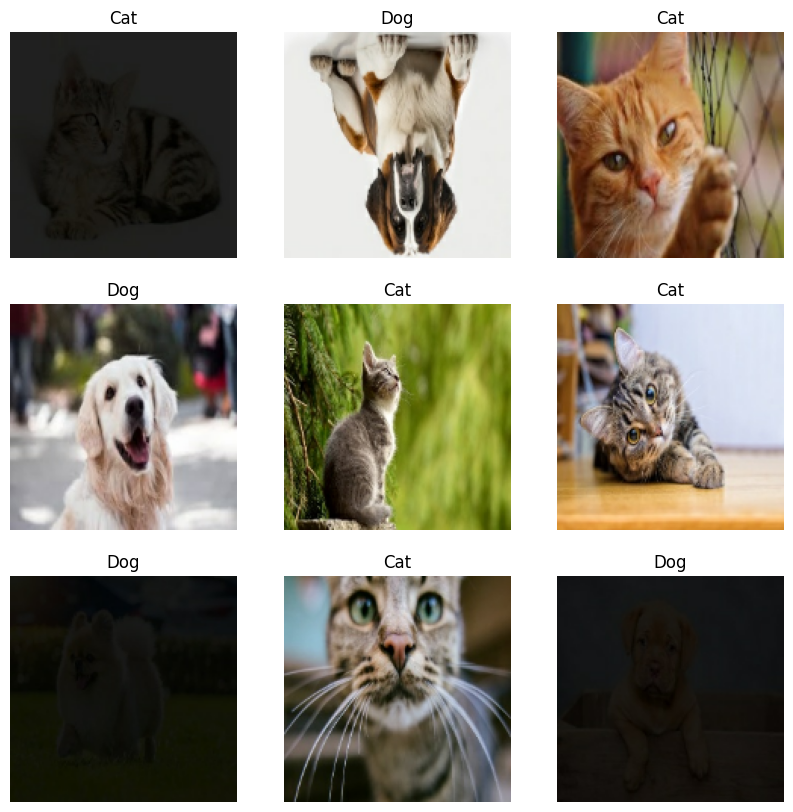

In [4]:
plt.figure(figsize = (10,10))
for images, labels in train_data.take(1): #So train_data.take(1) takes one batch, containing up to 32 images.(oru batch edukanum, where 1 batch = 32 images)
    for i in range(9): # athile first 9 images
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8')) # imshow() means image show.- Take this array of pixel values and display it as an image.
        # Take the i-th image → convert it from TensorFlow Tensor to NumPy array → convert pixel values to uint8 → display the image.
        plt.title(class_names[labels[i]])  # labels = [0, 1, 0, 0, 1, ...](till 9 images lables), 0 → cat, 1 → dog, For image i, we want its corresponding label:
        # so if label = 0, then find its class_name(that is cat), is printed
        plt.axis('off')
plt.show()

Build a cnn model

## 4. Build a Simple CNN Model
We construct a Convolutional Neural Network with alternating Conv2D and MaxPooling2D layers, followed by a Flatten layer and Dense layers for classification.

In [5]:
num_classes = 2 # datset has 2 categories
model = models.Sequential([layers.Rescaling(1./255, input_shape = (img_height, img_width, 3)), # This is called normalization/rescaling.
                           layers.Conv2D(16, 3, padding = 'same', activation = 'relu'), # Padding- same	Keeps height/width approximately the same, valid- 	No padding, so height/width become smaller
                           layers.MaxPooling2D(),layers.Conv2D(32, 3, padding = 'same', activation = 'relu'), layers.MaxPooling2D(), layers.Conv2D(64, 3, padding = 'same',activation = 'relu'), layers.MaxPooling2D(), layers.Flatten(), layers.Dense(128, activation = 'relu'), 
                           layers.Dense(num_classes)]) # The model produces 2 output values, corresponding to the two classes.
model.summary()

c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,178 (10.22 MB)

 Trainable params: 2,678,178 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

Compiling

In [6]:
model.compile(optimizer='adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),metrics = ['accuracy'])
# metrics=['accuracy'] - to show accuracy
# loss(eoor) calculation using SparseCategoricalCrossentropy, from_logits=True = tells it that your final layer gives raw scores rather than probabilities.
epochs = 20
history = model.fit(train_data, validation_data= val_data, epochs = epochs)

Epoch 1/20


c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.5408 - loss: 0.9244 - val_accuracy: 0.5306 - val_loss: 0.6936
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.4847 - loss: 0.6980 - val_accuracy: 0.4694 - val_loss: 0.6918
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.5459 - loss: 0.6939 - val_accuracy: 0.4694 - val_loss: 0.6929
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.5255 - loss: 0.6902 - val_accuracy: 0.4694 - val_loss: 0.6946
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5204 - loss: 0.6877 - val_accuracy: 0.4694 - val_loss: 0.6944
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.6020 - loss: 0.6835 - val_accuracy: 0.5714 - val_loss: 0.6873
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5510 - loss: 0.6694 - val_accuracy: 0.4694 - val_loss: 0.6985
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5867 - loss: 0.6581 - val_accuracy: 0.5918 - val_loss: 0.6711
Epo

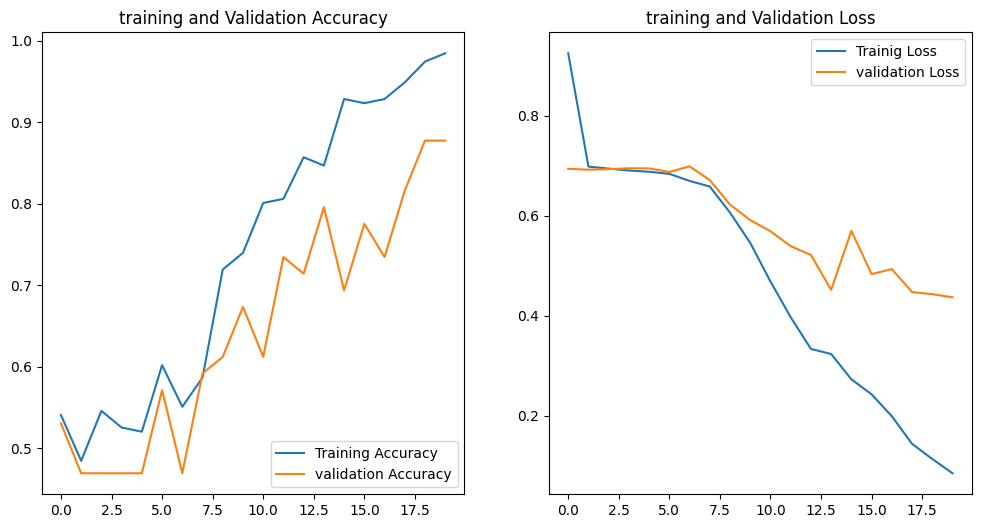

In [7]:
# plot accuracy and loss fn
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize = (12, 6))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label = 'Training Accuracy')
plt.plot(epochs_range, val_acc, label = 'validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label = 'Trainig Loss')
plt.plot(epochs_range, val_loss, label = 'validation Loss')
plt.legend(loc = 'upper right')
plt.title('training and Validation Loss')
plt.show()

| Metric                  | Your result | Simple meaning                                                           |
| ----------------------- | ----------: | ------------------------------------------------------------------------ |
| **Training accuracy**   |     **95%** | The model correctly classified about 95% of images it learned from       |
| **Validation accuracy** |     **82%** | The model correctly classified about 82% of new/unseen validation images |
| **Training loss**       |    **0.16** | The model's error on training images is relatively low                   |
| **Validation loss**     |    **0.58** | The model's error on validation images is higher than its training error |


In [8]:
# save the model
model.save('animal_cat_dog.keras')
print('Model Saved Successfully')

Model Saved Successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
This image most Likely belong to Cat with a 99.99 percent confidence


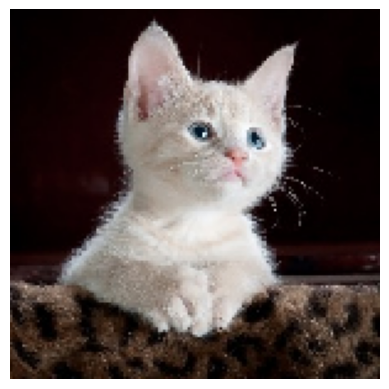

In [18]:
# predicting new image
test_image_path = r'C:\Users\POOJA\Downloads\datascience\deep_learnig\cat_dog\Cat\Cat_3.jpg'

if os.path.exists(test_image_path):
    img = tf.keras.utils.load_img(test_image_path, target_size= (img_height, img_width)) # load image
    img_array = tf.keras.utils.img_to_array(img) # converting into array
    img_array = tf.expand_dims(img_array, 0) 
    # 150 × 150 × 3 changes to 1 × 150 × 150 × 3 - 1 means, I am giving the model 1 image.
    
    
    predictions = model.predict(img_array)
    # beacuse the final layer is layers.Dense(num_classes) and: num_classes = 2, the model gives 2 raw scores. For example: Cat → 2.8, Dog → 1.1
    score = tf.nn.softmax(predictions[0]) # softmax() converts those raw scores into values that behave like probabilities.
    
    print('This image most Likely belong to {} with a {:.2f} percent confidence'.format(class_names[np.argmax(score)], 100*np.max(score)))
    # Suppose, class_names = ['Cat', 'Dog'], score = [0.845, 0.155], thne the output is This image most likely belongs to Cat with a 84.50 percent confidence
    
    # display the img
    plt.imshow(img) # display the image
    plt.axis('off')
    plt.show()
else:
    print(f'Image not found at {test_image_path}. please provide a valid path')